# Aula 02 — Métodos Baseados em Valores


## Notebook 01 — Intuição de valor, Equação de Bellman e Programação Dinâmica

**Disciplina:** Modelos de Aprendizagem por Reforço  
**Tema:** V(s), Q(s,a), Bellman, Policy Iteration, Value Iteration  
**Ambiente:** GridWorld 4×4 implementado do zero (sem Gymnasium)

Neste notebook, vamos estudar a base conceitual dos métodos baseados em valores em Reinforcement Learning. A ideia central é compreender como um agente pode aprender a avaliar estados e ações antes mesmo de executar um algoritmo de aprendizado por tentativa e erro. Para isso, trabalharemos com funções de valor, Equação de Bellman e Programação Dinâmica em um ambiente pequeno e totalmente controlado.

O objetivo não é apenas obter uma política ótima ao final da execução, mas observar como os valores se propagam pelo ambiente, como a recompensa futura influencia a decisão presente e por que a disponibilidade do modelo do ambiente torna possível calcular valores de forma sistemática. Esse ponto será essencial para entender, nos próximos notebooks, o que muda quando o agente não conhece o modelo e precisa aprender diretamente da experiência.

## Objetivos de aprendizagem



Ao final deste notebook, você deverá ser capaz de:

- explicar o que significa aprender uma função de valor;
- diferenciar valor de estado, representado por \(V(s)\), e valor de ação, representado por \(Q(s,a)\);
- interpretar a Equação de Bellman como uma relação entre recompensa imediata e valor futuro;
- compreender a diferença entre avaliação de política e busca por uma política ótima;
- implementar, em ambiente tabular, os princípios de Policy Evaluation, Policy Improvement, Policy Iteration e Value Iteration;
- reconhecer a principal limitação da Programação Dinâmica: a necessidade de conhecer o modelo completo do ambiente.

O notebook usa um GridWorld implementado do zero justamente para tornar explícitas as transições, recompensas e estados terminais. Essa escolha facilita a visualização do raciocínio por trás da Programação Dinâmica.

## Preparação do ambiente


Antes de construir o GridWorld e executar os algoritmos, vamos configurar as bibliotecas utilizadas no notebook. O foco será manter o experimento simples, reprodutível e visualmente interpretável.

Serão usadas principalmente as bibliotecas `numpy` e `matplotlib`. O `numpy` será responsável pela representação dos valores e das políticas, enquanto o `matplotlib` será usado para visualizar mapas de valor, políticas e evolução das iterações. Como o ambiente será implementado do zero, não será necessário usar Gymnasium neste notebook.

## Informações do notebook



| Item | Detalhe |
|---|---|
| **Aula** | Aula 02 — Métodos Baseados em Valores |
| **Notebook** | 01 — Intuição de valor, Bellman e Programação Dinâmica |
| **Seções** | 2.1, 2.2, 2.3 |
| **Tempo de leitura** | 18 min |
| **Tempo de execução (padrão)** | 2 min |
| **Exercícios** | 3 questões de autoavaliação |

### Pré-requisitos




- **Notebooks anteriores:** `00_guia_aula02.ipynb` — validação do ambiente.
- **Conceitos:** MDP, estados, ações, recompensa, fator de desconto (Aula 01, notebook 04).

### Competências para o Desafio Final



- Implementar Policy Iteration e Value Iteration em um ambiente com modelo disponível.
- Explicar como a Equação de Bellman define a relação recursiva entre valores de estados.
- Identificar por que a Programação Dinâmica não é aplicável a ambientes sem modelo.

### Recapitulando





A Aula 01 formalizou o MDP (estados, ações, recompensa, fator de desconto γ) e implementou um bandit ε-greedy — sem estado variável. O próximo passo natural é: **e quando o estado muda a cada passo e o modelo do ambiente está disponível?** Este notebook responde a essa pergunta com Programação Dinâmica.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import rl_utils
rl_utils.info_versoes()
rl_utils.configurar_matplotlib()
rl_utils.definir_seeds(42)

Biblioteca           Versão
--------------------------------
gymnasium            1.0.0
torch                2.11.0+cpu
numpy                2.4.2
matplotlib           3.10.8
pandas               3.0.1
scikit-learn         1.8.0


## Bloco 1 — Contexto e pergunta



Antes de aprender a agir, um agente precisa aprender a **avaliar**. A pergunta central deste notebook é:

> **O que significa dizer que um estado ou uma ação têm valor para um agente?**

Duas funções respondem a essa pergunta:

- **V(s)** — *função de valor de estado*: quão promissor é estar no estado *s*, considerando as recompensas futuras esperadas ao seguir uma política.
- **Q(s, a)** — *função valor-ação*: quão boa é a ação *a* quando o agente está no estado *s*.

Neste notebook, essas funções são calculadas de forma **exata**, porque o modelo do ambiente está completamente disponível. Isso define a **Programação Dinâmica (DP)**. Não há interação com o ambiente — o agente calcula tudo a partir do modelo.

**Mensagem principal:**
> *O agente aprende quão promissor é cada estado ao estimar funções de valor.*

In [2]:
# Instalação opcional das dependências
# %pip install numpy matplotlib

In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Versões utilizadas:")
print("numpy:", np.__version__)
print("matplotlib:", plt.matplotlib.__version__)

Versões utilizadas:
numpy: 2.4.2
matplotlib: 3.10.8


## O GridWorld como laboratório

Para estudar funções de valor e Programação Dinâmica, usaremos um GridWorld 4×4. Esse ambiente é simples o suficiente para que todos os estados e ações sejam visualizados diretamente, mas já contém os elementos necessários para representar um problema de decisão sequencial.

O agente começa no canto superior esquerdo, deve alcançar o objetivo no canto inferior direito e precisa evitar estados de buraco, que geram penalidade. Cada movimento em uma célula comum tem uma pequena penalidade, o que incentiva o agente a encontrar caminhos eficientes, e não apenas caminhos seguros.

A escolha por implementar o ambiente do zero é intencional. Em Programação Dinâmica, o agente precisa conhecer o modelo do ambiente: quais estados existem, quais ações são possíveis, para onde cada ação leva e qual recompensa é recebida em cada transição. Ao construir essas regras explicitamente, conseguimos observar por que a Programação Dinâmica funciona e por que ela depende de uma hipótese forte.



O GridWorld 4×4 é o ambiente mais simples em que é possível visualizar todos os conceitos de Programação Dinâmica. O agente parte do canto superior esquerdo e busca o objetivo no canto inferior direito. Dois estados de buraco impõem penalidade. Como o modelo completo está disponível — transições, recompensas e estados terminais — é possível calcular os valores exatos sem nenhuma interação com o ambiente.

In [4]:
class GridWorld:
    def __init__(self, rows=4, cols=4):
        self.rows = rows
        self.cols = cols
        self.n_states = rows * cols
        self.n_actions = 4  # 0=esquerda, 1=baixo, 2=direita, 3=cima
        self.estado_inicial = 0
        self.estado_meta = self.para_estado(rows - 1, cols - 1)
        # Dois buracos em posições intermediárias: (linha 1, col 1) e (linha 2, col 2)
        # Posicionados na diagonal do grid, criam obstáculos que obrigam o agente a desviar
        self.buracos = {self.para_estado(1, 1), self.para_estado(2, 2)}
        self.actions = {0: (0, -1), 1: (1, 0), 2: (0, 1), 3: (-1, 0)}

    def para_estado(self, r, c):
        return r * self.cols + c

    def para_posicao(self, s):
        return divmod(s, self.cols)

    def eh_terminal(self, s):
        return s == self.estado_meta or s in self.buracos

    def step(self, s, a):
        if self.eh_terminal(s):
            return s, 0.0, True
        r, c = self.para_posicao(s)
        dr, dc = self.actions[a]
        # Limita o movimento dentro dos limites do grid: o agente não sai das bordas
        # min/max garantem que linhas e colunas fiquem sempre no intervalo válido
        nr = min(max(r + dr, 0), self.rows - 1)
        nc = min(max(c + dc, 0), self.cols - 1)
        ns = self.para_estado(nr, nc)
        if ns == self.estado_meta:
            return ns, 1.0, True
        if ns in self.buracos:
            return ns, -1.0, True
        return ns, -0.04, False

env = GridWorld()
ARROWS = {0: '←', 1: '↓', 2: '→', 3: '↑'}

print(f"GridWorld {env.rows}×{env.cols}")
print(f"Estados: {env.n_states} | Ações: {env.n_actions}")
print(f"Início: {env.estado_inicial} | Objetivo: {env.estado_meta} | Buracos: {env.buracos}")

# Mapa visual
legenda = []
for s in range(env.n_states):
    if s == env.estado_meta: legenda.append('G')
    elif s in env.buracos: legenda.append('H')
    elif s == env.estado_inicial: legenda.append('S')
    else: legenda.append('.')
print("\nMapa do ambiente:")
for r in range(env.rows):
    print(' '.join(legenda[r * env.cols:(r + 1) * env.cols]))

GridWorld 4×4
Estados: 16 | Ações: 4
Início: 0 | Objetivo: 15 | Buracos: {10, 5}

Mapa do ambiente:
S . . .
. H . .
. . H .
. . . G


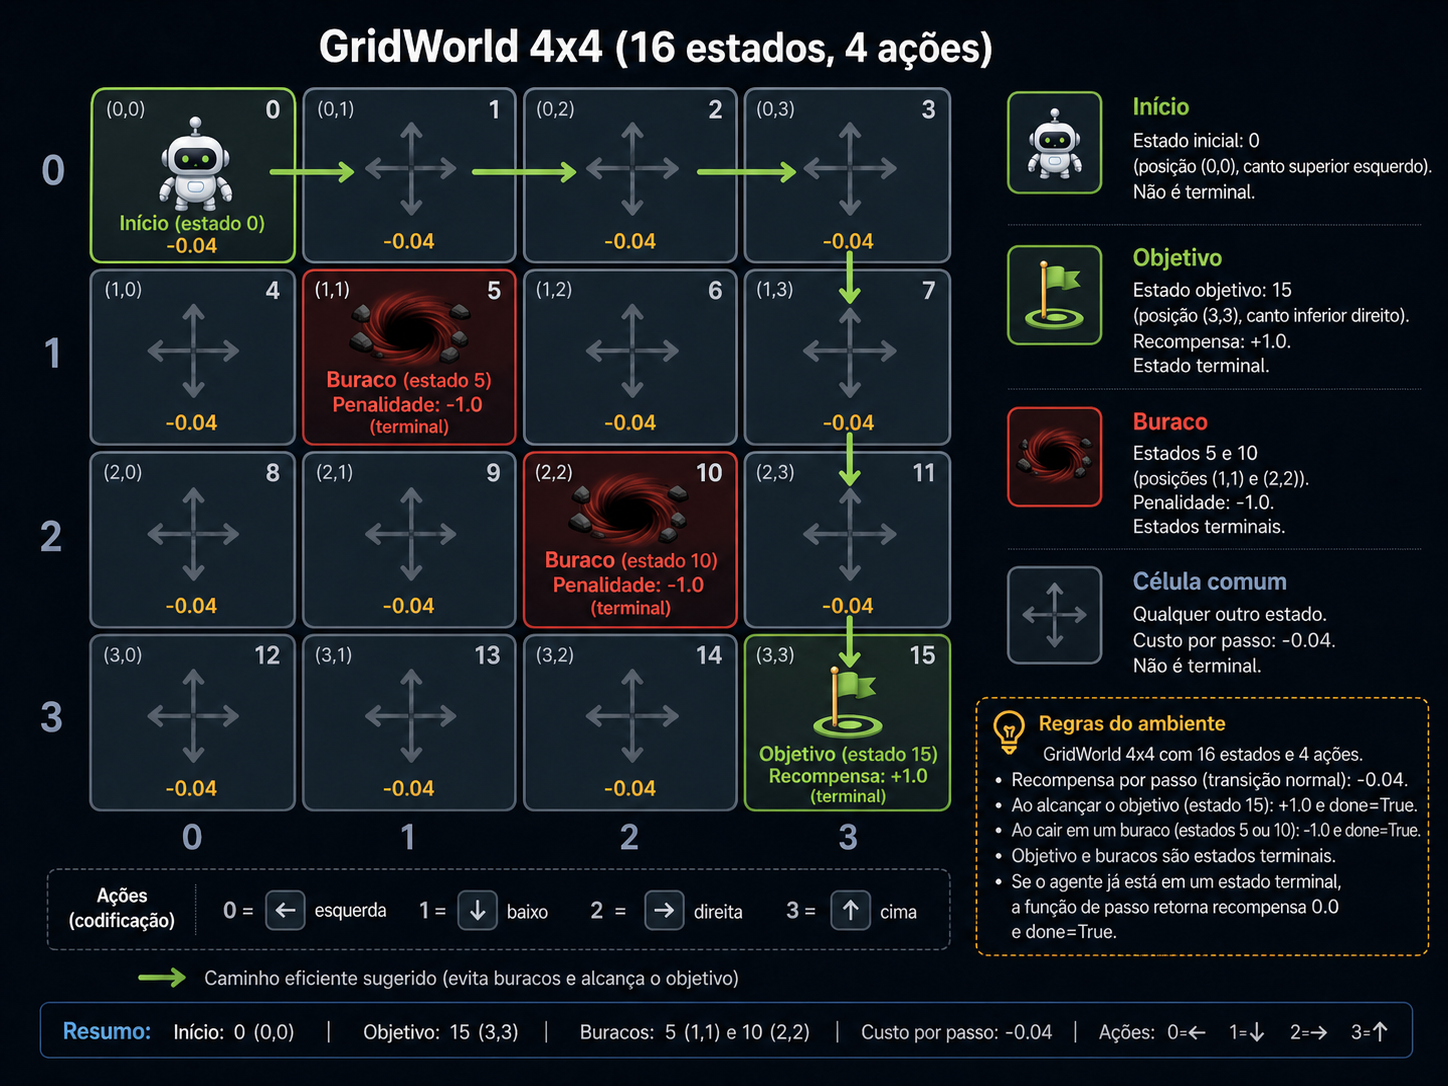

### Leitura inicial do ambiente



O mapa do GridWorld define a estrutura do problema. O estado `S` representa o ponto inicial do agente, o estado `G` representa o objetivo e os estados `H` representam buracos, isto é, estados terminais com recompensa negativa.

Essa configuração cria um dilema simples, mas importante: o agente precisa encontrar um caminho até o objetivo evitando regiões perigosas. Como há penalidade a cada passo, caminhos mais curtos tendem a ser melhores, desde que não levem o agente aos buracos.

Neste primeiro notebook, o agente ainda não aprenderá por tentativa e erro. Em vez disso, usará o modelo completo do ambiente para calcular, de forma iterativa, quais estados são mais promissores e quais ações conduzem a melhores consequências futuras.

## Bloco 2 — Função de valor: $V(s)$ e $Q(s,a)$

A função de valor de estado, representada por \(V(s)\), estima o retorno esperado a partir de um estado \(s\), assumindo que o agente seguirá determinada política a partir desse ponto. Em termos intuitivos, \(V(s)\) responde à pergunta:

> **Quão promissor é estar neste estado?**

Já a função valor-ação, representada por \(Q(s,a)\), estima o retorno esperado ao executar uma ação \(a\) em um estado \(s\), também considerando o comportamento futuro do agente. Ela responde à pergunta:

> **Quão promissora é esta ação neste estado?**

A diferença é importante. \(V(s)\) avalia a situação em que o agente se encontra. \(Q(s,a)\) avalia uma escolha concreta dentro dessa situação. Em métodos baseados em valores, a política pode ser derivada dessas estimativas: se o agente sabe quais ações têm maior valor, pode escolher aquelas que parecem levar a melhores retornos futuros.

Estas definições preparam o terreno para a **Equação de Bellman** (próxima seção), que formaliza como \(V(s)\) e \(Q(s,a)\) se relacionam com as recompensas imediatas e os valores dos estados seguintes.

## Bloco 3 — Equação de Bellman

A Equação de Bellman é a ideia central que conecta recompensa imediata e valor futuro. Ela formaliza uma intuição simples: o valor de um estado depende da recompensa que o agente recebe agora e do valor dos estados que ele poderá alcançar depois.

Para uma política fixa, a relação pode ser escrita como:

$V(s) = \sum_a \pi(a|s) \left[ R(s,a) + \gamma V(s') \right]$


Nessa expressão, $\pi(a|s)$ representa a probabilidade de escolher a ação $a$ no estado $s$, $R(s,a)$ representa a recompensa imediata, $s'$ representa o próximo estado e $\gamma$ é o fator de desconto.

O fator de desconto controla o peso do futuro. Quando $\gamma$ está próximo de 1, o agente valoriza recompensas futuras de forma mais intensa. Quando $\gamma$ está próximo de 0, o agente se torna mais imediatista.

No caso ótimo, o agente não calcula apenas o valor de uma política fixa. Ele busca a melhor ação possível:

$
V^*(s) = \max_a \left[ R(s,a) + \gamma V^*(s') \right]
$

Essa forma da equação será a base da Value Iteration.

In [5]:
gamma = 0.95

print(f"Fator de desconto γ = {gamma}")
print()
print("Bellman para política fixa:")
print("  V(s) = recompensa imediata esperada + γ × valor esperado do próximo estado")
print()
print("Bellman para optimalidade:")
print("  V*(s) = max sobre ações de [recompensa imediata + γ × melhor valor futuro]") 

Fator de desconto γ = 0.95

Bellman para política fixa:
  V(s) = recompensa imediata esperada + γ × valor esperado do próximo estado

Bellman para optimalidade:
  V*(s) = max sobre ações de [recompensa imediata + γ × melhor valor futuro]


## Exemplo: propagação de valor em uma cadeia de 3 estados

Este exemplo mínimo mostra a propagação de valor em sua forma mais simples. O GridWorld 4×4 logo a seguir aplica a mesma lógica a uma estrutura mais rica.

Antes de aplicar Bellman ao GridWorld completo, vamos observar um exemplo mínimo com três estados em sequência. O agente parte do estado 0, passa pelo estado 1 e chega ao estado 2, que representa o objetivo.

Esse exemplo permite visualizar a propagação de valor de forma muito direta. No início, todos os estados têm valor zero. Quando a recompensa do objetivo é incorporada, o estado imediatamente anterior passa a ter valor alto. Em seguida, esse valor se propaga para o estado inicial, descontado pelo fator $\gamma$.

A ideia essencial é que o valor não aparece de uma só vez em todos os lugares. Ele se propaga a partir das consequências futuras conhecidas.

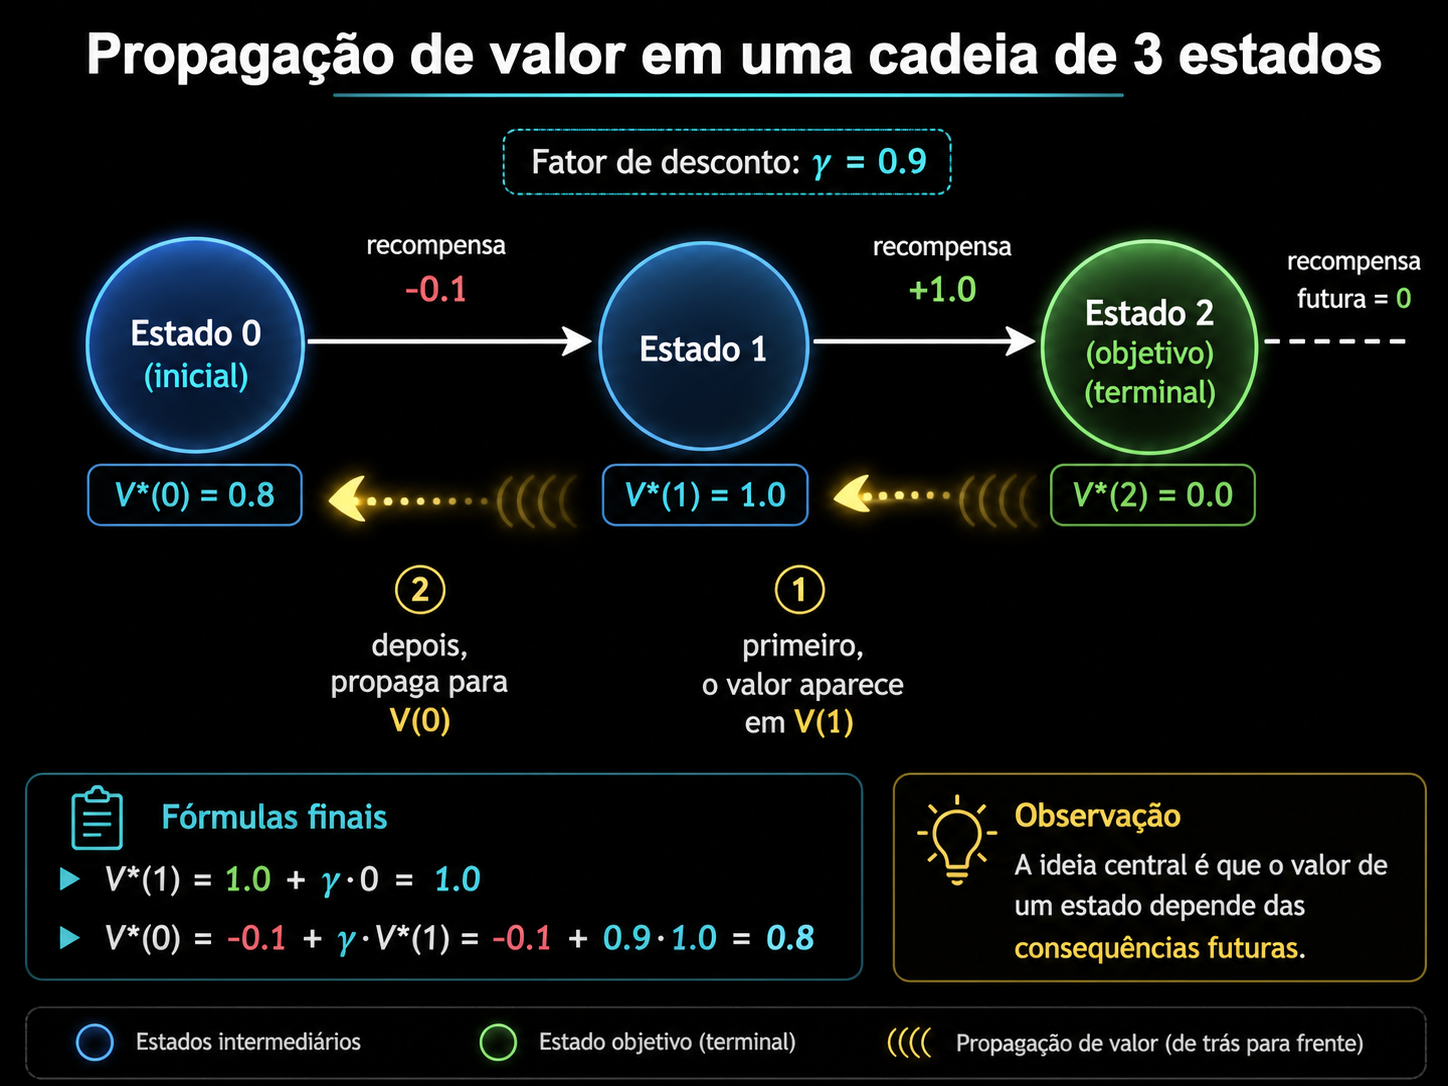

In [6]:
# Cadeia de 3 estados: 0 → 1 → 2(objetivo)
# R(0→1) = -0.1, R(1→2) = +1.0; gamma = 0.9
GAMMA = 0.9
recompensas_cadeia = [-0.1, 1.0, 0.0]     # recompensa ao SAIR de cada estado
sucessor_cadeia = [1, 2, 2]               # único sucessor (determinístico)

V_cadeia = np.zeros(3)
print(f"{'Varredura':>9} | {'V(0)':>7} | {'V(1)':>7} | {'V(2)':>7}")
print("-" * 42)
print(f"{'0 (inicial)':>9} | {V_cadeia[0]:7.4f} | {V_cadeia[1]:7.4f} | {V_cadeia[2]:7.4f}")

for sweep in range(1, 8):
    nova_V = V_cadeia.copy()
    for s in range(2):   # estado 2 é terminal, mantém 0
        ns = sucessor_cadeia[s]
        nova_V[s] = recompensas_cadeia[s] + GAMMA * V_cadeia[ns]
    V_cadeia = nova_V
    print(f"{sweep:>9} | {V_cadeia[0]:7.4f} | {V_cadeia[1]:7.4f} | {V_cadeia[2]:7.4f}")

print("\nConvengência esperada:")
print(f"  V*(1) = 1.0 × gamma^0 = {1.0:.4f}")
print(f"  V*(0) = -0.1 + gamma × V*(1) = {-0.1 + GAMMA * 1.0:.4f}")

Varredura |    V(0) |    V(1) |    V(2)
------------------------------------------
0 (inicial) |  0.0000 |  0.0000 |  0.0000
        1 | -0.1000 |  1.0000 |  0.0000
        2 |  0.8000 |  1.0000 |  0.0000
        3 |  0.8000 |  1.0000 |  0.0000
        4 |  0.8000 |  1.0000 |  0.0000
        5 |  0.8000 |  1.0000 |  0.0000
        6 |  0.8000 |  1.0000 |  0.0000
        7 |  0.8000 |  1.0000 |  0.0000

Convengência esperada:
  V*(1) = 1.0 × gamma^0 = 1.0000
  V*(0) = -0.1 + gamma × V*(1) = 0.8000


### Interpretação do exemplo da cadeia



O resultado da cadeia mostra a lógica recursiva de Bellman em sua forma mais simples. O estado mais próximo do objetivo recebe valor alto porque leva diretamente a uma recompensa positiva. O estado inicial também se torna valioso, mas seu valor depende do estado seguinte e do fator de desconto.

Essa propagação é a base de muitos algoritmos de Reinforcement Learning. Mesmo em ambientes maiores, a intuição permanece a mesma: estados próximos de boas consequências tendem a receber valores maiores, enquanto estados que levam a penalidades ou trajetórias ruins tendem a receber valores menores.

O ponto mais importante é perceber que o agente não precisa receber recompensa imediata em todos os estados. Um estado pode ser valioso porque conduz a bons estados futuros.

## Funções auxiliares de visualização

In [7]:
def exibir_valores(valores, env):
    grade = valores.reshape(env.rows, env.cols)
    for r in range(env.rows):
        row = []
        for c in range(env.cols):
            s = env.para_estado(r, c)
            if s == env.estado_meta: row.append('  G   ')
            elif s in env.buracos: row.append('  H   ')
            else: row.append(f'{grade[r, c]:5.2f} ')
        print(' | '.join(row))
    print()

def exibir_politica(acoes_politica, env):
    for r in range(env.rows):
        row = []
        for c in range(env.cols):
            s = env.para_estado(r, c)
            if s == env.estado_meta: row.append('G')
            elif s in env.buracos: row.append('H')
            else: row.append(ARROWS[int(acoes_politica[s])])
        print(' '.join(row))
    print()

def avaliar_um_passo(env, V, s, gamma=0.95):
    """Calcula Q(s,a) para todas as ações em s usando V(s') já estimado.
    Operação de lookahead de um passo — conecta V(s) a Q(s,a) e é a base
    de melhorar_politica: para cada estado, qual ação leva ao melhor V(s')?"""
    q = np.zeros(env.n_actions)
    for a in range(env.n_actions):
        ns, recompensa, feito = env.step(s, a)
        q[a] = recompensa + gamma * V[ns] * (0 if feito else 1)
    return q

print("Funções auxiliares definidas.")

Funções auxiliares definidas.


## Programação Dinâmica: três operações em sequência

As seções a seguir cobrem as três operações fundamentais da Programação Dinâmica. Elas não são métodos independentes — cada uma constrói sobre a anterior:

1. **Avaliação de Política (Policy Evaluation):** dado um comportamento fixo, calcular quanto cada estado vale.
2. **Melhoria de Política (Policy Improvement):** dado o valor de cada estado, encontrar um comportamento melhor.
3. **Iteração de Política (Policy Iteration):** combinar avaliação e melhoria em ciclos repetidos até convergir na política ótima.

Uma variante — **Value Iteration** — fusiona as etapas 1 e 2 em um único sweep, obtendo a política ótima sem separar explicitamente as duas fases.

## Avaliação de Política


A primeira operação clássica da Programação Dinâmica é a avaliação de política, ou *Policy Evaluation*. Nessa etapa, a política do agente permanece fixa. O objetivo não é melhorar o comportamento ainda, mas calcular o valor esperado dos estados assumindo que o agente continuará agindo de acordo com essa política.

Em termos intuitivos, a pergunta é:

> **Se o agente continuar seguindo esta política, qual será o valor esperado de cada estado?**

Essa pergunta é importante porque separa duas tarefas que muitas vezes aparecem misturadas: avaliar um comportamento e melhorar esse comportamento. Primeiro, entendemos as consequências de uma política. Depois, usamos essa avaliação para construir uma política melhor.

**Algoritmo — Avaliação de Política (4 passos):**

1. **Inicializar:** V(s) ← 0 para todos os estados s
2. **Varrer:** para cada estado s não terminal, aplicar a Equação de Bellman:
   V(s) ← Σ_a π(a|s) · [R(s,a) + γ · V(s')]
3. **Medir convergência:** δ ← max_s |V_novo(s) − V_antigo(s)|
4. **Repetir** os passos 2–3 até δ < θ (limiar de convergência)

Cada varredura percorre todos os estados uma vez. Múltiplas varreduras são necessárias porque o valor de cada estado depende dos valores dos estados vizinhos — que por sua vez dependem dos seus vizinhos. O processo propaga informação de valor a partir dos estados terminais até os estados mais distantes.

In [8]:
def avaliar_politica(env, politica, gamma=0.95, theta=1e-6, max_sweeps=300):
    """
    Avalia a função de valor V(s) para uma política fixa.

    Esta função implementa Policy Evaluation por varreduras sucessivas de Bellman.
    A política não é alterada durante o processo. O objetivo é apenas estimar
    quanto vale cada estado quando o agente segue a política informada.

    Parâmetros:
    - env: ambiente GridWorld, com estados, ações, transições e recompensas.
    - politica: matriz de probabilidades com formato [n_estados, n_acoes].
                politica[s][a] indica a probabilidade de escolher a ação a no estado s.
    - gamma: fator de desconto das recompensas futuras.
    - theta: tolerância usada como critério de convergência.
    - max_sweeps: número máximo de varreduras completas sobre os estados.

    Retorno:
    - V: vetor com o valor estimado de cada estado.
    """

    # Inicializa V(s) com zero para todos os estados.
    # No início, o agente ainda não atribui valor a nenhuma posição do ambiente.
    V = np.zeros(env.n_states, dtype=float)

    # Cada sweep representa uma varredura completa sobre todos os estados.
    # Em cada varredura, aplicamos a atualização de Bellman para a política fixa.
    for sweep in range(1, max_sweeps + 1):

        # delta mede a maior mudança observada em V(s) durante esta varredura.
        # Quando delta fica muito pequeno, entendemos que os valores praticamente convergiram.
        delta = 0.0

        # Criamos uma cópia para armazenar os novos valores.
        # Isso evita que a atualização de um estado interfira imediatamente
        # no cálculo de outro estado dentro da mesma varredura.
        new_V = V.copy()

        # Percorre todos os estados do ambiente.
        for s in range(env.n_states):

            # Estados terminais não são atualizados.
            # Uma vez que o agente chegou ao objetivo ou caiu em um buraco,
            # o episódio terminou e não há valor futuro a propagar a partir dali.
            if env.eh_terminal(s):
                continue

            # Acumulador do novo valor do estado s.
            # Ele será calculado como uma média ponderada sobre as ações possíveis,
            # considerando as probabilidades definidas pela política.
            v = 0.0

            # Percorre todas as ações possíveis e suas probabilidades
            # de serem escolhidas no estado s segundo a política fixa.
            for a, prob in enumerate(politica[s]):

                # Simula a transição resultante de executar a ação a no estado s.
                # ns: próximo estado
                # recompensa: recompensa imediata recebida
                # feito: indica se a transição encerra o episódio
                ns, recompensa, feito = env.step(s, a)

                # Atualização de Bellman para avaliação de política:
                #
                # V(s) = soma_a pi(a|s) * [r + gamma * V(s')]
                #
                # Se a transição termina o episódio, não há valor futuro.
                # Por isso, multiplicamos o termo futuro por 0 quando feito=True.
                v += prob * (recompensa + gamma * V[ns] * (0 if feito else 1))

            # Armazena o novo valor calculado para o estado s.
            new_V[s] = v

            # Atualiza delta com a maior diferença entre o valor antigo e o novo.
            # Esse valor será usado para verificar a convergência da avaliação.
            delta = max(delta, abs(new_V[s] - V[s]))

        # Substitui a função de valor antiga pela nova após completar a varredura.
        V = new_V

        # Critério de parada:
        # se a maior alteração em qualquer estado for menor que theta,
        # consideramos que a função de valor convergiu.
        if delta < theta:
            print(f"Policy Evaluation convergiu no sweep {sweep} (delta={delta:.2e})")
            break

    # Retorna os valores estimados para todos os estados sob a política fixa.
    return V


# Cria uma política aleatória uniforme.
# Em cada estado, todas as ações têm a mesma probabilidade de serem escolhidas.
# Como env.n_actions = 4, cada ação terá probabilidade 1/4 = 0.25.
politica_aleatoria = np.ones((env.n_states, env.n_actions)) / env.n_actions


# Avalia a função de valor V(s) quando o agente segue a política aleatória.
# O resultado mostra o valor esperado de cada estado se o agente agir ao acaso.
V_aleatoria = avaliar_politica(env, politica_aleatoria)


# Exibe os valores encontrados para cada estado do GridWorld.
# Estados mais próximos do objetivo tendem a ter valores maiores,
# enquanto estados próximos de buracos ou trajetórias ruins tendem a ter valores menores.
print("\nV(s) sob política aleatória uniforme:")
exibir_valores(V_aleatoria, env)

Policy Evaluation convergiu no sweep 69 (delta=8.49e-07)

V(s) sob política aleatória uniforme:
-0.89  | -0.90  | -0.83  | -0.73 
-0.90  |   H    | -0.86  | -0.62 
-0.83  | -0.86  |   H    | -0.22 
-0.73  | -0.62  | -0.22  |   G   



A avaliação de política mostra como os valores se organizam quando o agente segue um comportamento fixo. Se a política for aleatória ou pouco eficiente, alguns estados podem ter valores baixos mesmo estando relativamente próximos do objetivo, porque o agente ainda corre risco de tomar ações ruins ou caminhar para buracos.

Essa etapa deixa claro que o valor de um estado não depende apenas da geometria do ambiente. Ele depende também da política seguida. O mesmo estado pode ter valor alto sob uma boa política e valor baixo sob uma política ruim.

Por isso, avaliar uma política é apenas o primeiro passo. A partir da função de valor estimada, podemos perguntar quais ações parecem melhores em cada estado. Essa pergunta nos leva à etapa de melhoria de política.

## Melhoria de Política


**Por que avaliar nos permite melhorar?** A avaliação de política nos fornece V(s) — o retorno esperado estado a estado, sob a política atual. Com essa informação, podemos fazer uma pergunta concreta: existe algum estado onde trocar de ação produziria um V(s') maior a partir do próximo passo? Se sim, a troca melhora a política. Essa é a conexão direta entre as duas operações.

Depois de avaliar uma política, podemos tentar melhorá-la. A melhoria de política consiste em escolher, para cada estado, a ação que parece produzir o maior retorno esperado com base nos valores já calculados.

A ideia pode ser descrita da seguinte forma:

1. avaliamos a política atual;
2. observamos, em cada estado, qual ação leva ao melhor valor futuro;
3. atualizamos a política para favorecer essa ação;
4. repetimos o processo até que a política pare de mudar.

Esse procedimento conecta duas operações fundamentais: **avaliar** e **melhorar**. Quando essas etapas são alternadas até a estabilidade, temos Policy Iteration.

In [9]:
def melhorar_politica(env, V, gamma=0.95):
    """
    Deriva uma política gulosa a partir de uma função de valor V(s).

    Esta função implementa a etapa de Policy Improvement.
    A ideia é: dado um conjunto de valores V(s), avaliamos qual ação parece
    melhor em cada estado, olhando apenas um passo à frente.

    Em outras palavras, para cada estado s, calculamos o valor esperado de
    cada ação possível a partir de:

        Q(s, a) = recompensa imediata + gamma * V(s')

    Depois, escolhemos a ação com maior Q(s, a).

    Parâmetros:
    - env: ambiente GridWorld, com estados, ações, transições e recompensas.
    - V: vetor com os valores estimados dos estados.
    - gamma: fator de desconto usado para ponderar o valor futuro.

    Retorno:
    - nova_politica: matriz [n_estados, n_acoes] representando uma política determinística.
                     Em cada estado não terminal, a melhor ação recebe probabilidade 1.0.
    - gulosa: vetor com o índice da melhor ação escolhida para cada estado.
    """

    # Vetor que armazenará, para cada estado, a ação considerada melhor.
    # Cada posição gulosa[s] conterá o índice da ação escolhida:
    # 0 = esquerda, 1 = baixo, 2 = direita, 3 = cima.
    gulosa = np.zeros(env.n_states, dtype=int)

    # Matriz da nova política.
    # Cada linha representa um estado e cada coluna representa uma ação.
    # Inicialmente, todas as probabilidades são zero.
    nova_politica = np.zeros((env.n_states, env.n_actions))

    # Percorre todos os estados do ambiente.
    for s in range(env.n_states):

        # Estados terminais não precisam de melhoria de política.
        # Se o agente já chegou ao objetivo ou caiu em um buraco,
        # o episódio terminou e nenhuma ação futura será escolhida.
        if env.eh_terminal(s):
            continue

        # Calcula os valores Q(s, a) para todas as ações possíveis no estado s.
        # Essa função faz um lookahead de um passo:
        # simula cada ação, observa o próximo estado e combina recompensa imediata
        # com o valor futuro V(s').
        q = avaliar_um_passo(env, V, s, gamma)

        # Seleciona a ação com maior valor Q(s, a).
        # np.argmax(q) retorna o índice da ação mais promissora segundo V(s).
        melhor = int(np.argmax(q))

        # Registra a melhor ação no vetor da política gulosa.
        gulosa[s] = melhor

        # Como a política melhorada é determinística,
        # atribuímos probabilidade 1.0 à melhor ação.
        # Todas as demais ações permanecem com probabilidade 0.0.
        nova_politica[s, melhor] = 1.0

    # Retorna a matriz da nova política e o vetor com as ações escolhidas.
    return nova_politica, gulosa


# Aplica Policy Improvement usando os valores obtidos pela avaliação
# da política aleatória uniforme.
#
# A função V_aleatoria informa o quanto cada estado parece promissor
# quando o agente age aleatoriamente. A partir desses valores, agora
# derivamos uma política gulosa: em cada estado, escolhemos a ação que
# leva ao melhor próximo estado esperado.
politica_melhorada, acoes_melhoradas = melhorar_politica(env, V_aleatoria)


# Exibe a política melhorada em formato visual.
# O resultado esperado é um mapa de ações que já tende a apontar para
# trajetórias mais promissoras do que a política aleatória original.
print("Política melhorada a partir dos valores da política aleatória:")
exibir_politica(acoes_melhoradas, env)

Política melhorada a partir dos valores da política aleatória:
← → → ↓
↓ H → ↓
↓ ↓ H ↓
→ → → G



## Iteração de Política


Policy Iteration combina avaliação e melhoria de política. O algoritmo começa com uma política inicial, avalia seus valores e, em seguida, melhora a política com base nesses valores. Esse ciclo continua até que a política se torne estável.

A intuição é simples: se, após uma rodada de melhoria, nenhuma ação muda, isso indica que a política atual já é gulosa em relação aos valores estimados. Nesse caso, o algoritmo encontrou uma política ótima para o ambiente, considerando o modelo conhecido e o fator de desconto definido.

No GridWorld, esse processo permite observar a política evoluir de um comportamento inicial possivelmente ruim para uma sequência de ações que conduz o agente ao objetivo evitando penalidades.

**Por que Policy Iteration converge para a política ótima?**

Cada ciclo de melhoria garante que a nova política π' é *ao menos tão boa* quanto a anterior π. Esse resultado é o **Teorema de Melhoria de Política**: se π' é construída escolhendo a ação gulosa segundo V_π, então V_π'(s) ≥ V_π(s) para todo estado s.

Quando a melhoria de política para de mudar as ações — ou seja, quando π' = π — atingimos um **ponto fixo**. Um ponto fixo da melhoria é, por definição, uma política ótima: nenhuma outra política produz retornos maiores. A convergência é garantida porque o espaço de políticas determinísticas é finito — o algoritmo não pode melhorar para sempre.

In [10]:
def iterar_politica(env, gamma=0.95, theta=1e-6, max_iter=50):
    """
    Executa Policy Iteration até a política estabilizar.

    Policy Iteration alterna duas etapas principais:

    1. Policy Evaluation:
       avalia a política atual, estimando V(s) para todos os estados.

    2. Policy Improvement:
       melhora a política atual, escolhendo de forma gulosa a melhor ação
       em cada estado com base nos valores V(s) calculados.

    O processo se repete até que a política pare de mudar. Quando a política
    melhorada é igual à política anterior, dizemos que ela estabilizou.

    Parâmetros:
    - env: ambiente GridWorld.
    - gamma: fator de desconto das recompensas futuras.
    - theta: tolerância usada na etapa de avaliação de política.
    - max_iter: número máximo de ciclos avaliação → melhoria.

    Retorno:
    - politica: matriz da política final.
    - gulosa: vetor com a ação escolhida em cada estado pela política final.
    - V: valores estimados dos estados para a política final.
    - iteration: número de iterações realizadas até a convergência.
    """

    # Inicializa a política como aleatória uniforme.
    # Em cada estado, todas as ações começam com a mesma probabilidade.
    # Como há env.n_actions ações, cada uma recebe probabilidade 1 / env.n_actions.
    politica = np.ones((env.n_states, env.n_actions)) / env.n_actions

    # Cada iteração executa um ciclo completo de:
    # avaliação da política atual + melhoria da política.
    for iteration in range(1, max_iter + 1):

        # Etapa 1 — Policy Evaluation.
        # Calcula V(s) assumindo que o agente segue a política atual.
        #
        # Nesta etapa, a política ainda não muda.
        # O objetivo é apenas estimar quanto vale cada estado sob essa política.
        V = avaliar_politica(env, politica, gamma=gamma, theta=theta)

        # Etapa 2 — Policy Improvement.
        # Usa os valores V(s) recém-calculados para derivar uma política melhor.
        #
        # Para cada estado, a nova política escolhe a ação que maximiza
        # a estimativa de retorno de um passo à frente.
        nova_politica, gulosa = melhorar_politica(env, V, gamma=gamma)

        # Converte a política atual em um vetor de ações gulosas.
        #
        # Como a política é representada por uma matriz de probabilidades,
        # np.argmax(politica, axis=1) retorna, para cada estado, a ação
        # com maior probabilidade na política atual.
        gulosa_antiga = np.argmax(politica, axis=1)

        # Verifica se a política estabilizou.
        #
        # Se a ação escolhida em cada estado for a mesma antes e depois
        # da melhoria, não há mais mudança relevante na política.
        # Esse é o critério de convergência de Policy Iteration.
        if np.array_equal(gulosa_antiga, gulosa):
            print(f"Policy Iteration convergiu na iteração {iteration}")

            # Retorna a política final, a versão gulosa, os valores associados
            # e o número de iterações necessárias para convergir.
            return politica, gulosa, V, iteration

        # Se a política ainda mudou, substituímos a política antiga
        # pela política melhorada e repetimos o ciclo.
        politica = nova_politica

    # Caso o limite máximo de iterações seja atingido antes da estabilização,
    # retorna o melhor resultado encontrado até o momento.
    return politica, gulosa, V, max_iter


# Executa Policy Iteration no ambiente.
#
# O algoritmo começa com uma política aleatória uniforme, avalia seus valores,
# melhora as ações com base nesses valores e repete o processo até que a
# política pare de mudar.
pi_politica, pi_gulosa, pi_valores, pi_iters = iterar_politica(env)


# Exibe a política encontrada após a convergência.
#
# Em um GridWorld determinístico e pequeno, Policy Iteration tende a encontrar
# rapidamente uma política ótima ou estável, pois o modelo do ambiente é conhecido
# e todas as transições podem ser avaliadas de forma explícita.
print(f"\nPolítica ótima — Policy Iteration ({pi_iters} iterações):")
exibir_politica(pi_gulosa, env)


# Exibe os valores V(s) associados à política final.
#
# Esses valores indicam o retorno esperado a partir de cada estado quando
# o agente segue a política encontrada por Policy Iteration.
print("Valores ótimos:")
exibir_valores(pi_valores, env)

Policy Evaluation convergiu no sweep 69 (delta=8.49e-07)
Policy Evaluation convergiu no sweep 208 (delta=9.79e-07)
Policy Evaluation convergiu no sweep 7 (delta=0.00e+00)
Policy Iteration convergiu na iteração 3

Política ótima — Policy Iteration (3 iterações):
↓ → ↓ ↓
↓ H → ↓
↓ ↓ H ↓
→ → → G

Valores ótimos:
 0.59  |  0.67  |  0.74  |  0.82 
 0.67  |   H    |  0.82  |  0.91 
 0.74  |  0.82  |   H    |  1.00 
 0.82  |  0.91  |  1.00  |   G   



### Por que a convergência foi tão rápida?

Policy Iteration convergiu em apenas 3 iterações porque o GridWorld 4×4 é um problema estruturalmente simples. Em cada iteração, a política melhora apenas nos estados onde existe uma ação claramente melhor do que as demais.

Na iteração 1, a avaliação da política aleatória revela que estados próximos a buracos têm valor muito baixo. A melhoria reorienta o agente para longe dessas posições. Nas iterações 2 e 3, os ajustes restantes são pequenos — a política converge antes mesmo de explorar todas as possibilidades.

Em ambientes maiores, com estados mais interdependentes ou recompensas mais esparsas, Policy Iteration pode exigir dezenas de iterações antes de estabilizar. O número de iterações é uma medida indireta da complexidade do problema.

A política final obtida por Policy Iteration representa uma solução ótima para o GridWorld sob as regras definidas. As setas indicam, em cada estado não terminal, a ação preferida pelo agente.

É importante observar que essa política não foi aprendida por tentativa e erro. O agente não precisou executar episódios, explorar o ambiente ou acumular experiências. Ele usou o modelo completo para calcular as consequências esperadas de cada decisão.

Esse é o grande poder da Programação Dinâmica: quando o modelo está disponível, é possível resolver o problema de forma sistemática. Ao mesmo tempo, essa também é sua principal limitação, pois em muitos ambientes reais o modelo não está disponível de forma explícita.

## Value Iteration


Value Iteration oferece uma alternativa mais direta à Policy Iteration. Em vez de alternar explicitamente entre avaliação completa e melhoria de política, o algoritmo aplica repetidamente a atualização de Bellman ótima.

A cada iteração, o valor de cada estado é atualizado considerando a melhor ação possível naquele momento:

$V(s) \leftarrow \max_a \left[ R(s,a) + \gamma V(s') \right]$

Depois que os valores convergem, a política ótima pode ser extraída escolhendo, em cada estado, a ação que maximiza a expressão acima.

A principal diferença didática é que Policy Iteration enfatiza a separação entre avaliar e melhorar, enquanto Value Iteration mistura essas duas ideias em uma única atualização orientada à optimalidade.

In [11]:
def iterar_valores(env, gamma=0.95, theta=1e-6, max_sweeps=300, verbose_every=4):
    """
    Executa Value Iteration até a função de valor convergir.

    Value Iteration atualiza diretamente V(s) usando a equação de
    optimalidade de Bellman. Diferentemente de Policy Iteration, aqui
    não avaliamos uma política fixa por completo antes de melhorá-la.

    Em cada estado, o algoritmo calcula o valor de todas as ações possíveis
    e já escolhe o maior valor encontrado:

        V(s) = max_a [recompensa + gamma * V(s')]

    Assim, a melhoria da política está embutida na própria atualização
    dos valores.

    Parâmetros:
    - env: ambiente GridWorld.
    - gamma: fator de desconto das recompensas futuras.
    - theta: tolerância usada como critério de convergência.
    - max_sweeps: número máximo de varreduras completas sobre os estados.
    - verbose_every: frequência de impressão do progresso das atualizações.

    Retorno:
    - V: vetor com os valores ótimos estimados para cada estado.
    - vi_gulosa: vetor com a melhor ação para cada estado, derivada de V.
    - sweep: número de sweeps executados até a convergência.
    """

    # Inicializa V(s) com zero para todos os estados.
    # No início, o agente ainda não possui nenhuma estimativa sobre
    # quais estados são mais ou menos promissores.
    V = np.zeros(env.n_states, dtype=float)

    # Cada sweep corresponde a uma varredura completa sobre todos os estados.
    # A cada varredura, os valores são atualizados usando a melhor ação possível.
    for sweep in range(1, max_sweeps + 1):

        # delta registra a maior alteração em V(s) durante a varredura atual.
        # Ele será usado para decidir se o algoritmo já convergiu.
        delta = 0.0

        # Cria uma cópia dos valores atuais.
        # Os novos valores serão escritos em new_V, preservando V como referência
        # para os cálculos desta varredura.
        new_V = V.copy()

        # Percorre todos os estados do ambiente.
        for s in range(env.n_states):

            # Estados terminais não são atualizados.
            # No objetivo ou em buracos, o episódio termina; portanto,
            # não há decisão futura a ser otimizada.
            if env.eh_terminal(s):
                continue

            # Calcula Q(s, a) para todas as ações possíveis a partir do estado s.
            #
            # A função avaliar_um_passo faz o lookahead de um passo:
            # para cada ação, simula a transição, observa a recompensa imediata
            # e combina essa recompensa com o valor estimado do próximo estado.
            q = avaliar_um_passo(env, V, s, gamma)

            # Atualização de optimalidade de Bellman.
            #
            # Em vez de calcular uma média ponderada pelas ações de uma política,
            # como em Policy Evaluation, Value Iteration escolhe diretamente
            # o maior valor entre as ações possíveis.
            new_V[s] = np.max(q)

            # Atualiza delta com a maior diferença entre o valor antigo
            # e o novo valor calculado para qualquer estado.
            delta = max(delta, abs(new_V[s] - V[s]))

        # Após completar a varredura, substituímos V pelos novos valores.
        V = new_V

        # Exibe o progresso periodicamente.
        # Isso ajuda a observar a redução gradual de delta e a convergência
        # da função de valor ao longo das varreduras.
        if sweep % verbose_every == 0 or sweep == 1:
            print(f"Sweep {sweep:>3} | delta = {delta:.6f}")

        # Critério de parada:
        # se a maior mudança de valor entre duas varreduras for menor que theta,
        # consideramos que V(s) convergiu.
        if delta < theta:
            print(f"Value Iteration convergiu no sweep {sweep}")
            break

    # Depois que os valores convergem, derivamos a política gulosa.
    #
    # A política ótima é obtida escolhendo, em cada estado, a ação que maximiza
    # recompensa imediata + valor futuro. Neste ponto, V já representa uma boa
    # aproximação dos valores ótimos.
    _, vi_gulosa = melhorar_politica(env, V, gamma=gamma)

    # Retorna os valores estimados, a política gulosa derivada desses valores
    # e o número de sweeps executados.
    return V, vi_gulosa, sweep


# Executa Value Iteration no ambiente.
#
# O algoritmo atualiza diretamente os valores dos estados com base na melhor
# ação possível em cada ponto, até que as mudanças fiquem pequenas o suficiente.
vi_valores, vi_gulosa, vi_sweeps = iterar_valores(env)


# Exibe a política ótima derivada dos valores encontrados.
#
# Diferentemente de Policy Iteration, a política não foi avaliada e melhorada
# em ciclos separados. Ela é extraída apenas ao final, a partir da função de
# valor já aproximada pela equação de optimalidade de Bellman.
print(f"\nPolítica ótima — Value Iteration ({vi_sweeps} sweeps):")
exibir_politica(vi_gulosa, env)

Sweep   1 | delta = 1.000000
Sweep   4 | delta = 0.857375
Value Iteration convergiu no sweep 7

Política ótima — Value Iteration (7 sweeps):
↓ → ↓ ↓
↓ H → ↓
↓ ↓ H ↓
→ → → G



A Value Iteration mostra a propagação progressiva dos valores ótimos pelo ambiente. Estados próximos do objetivo tendem a receber valores altos, desde que não estejam conectados a trajetórias perigosas. Estados próximos dos buracos ou de caminhos longos tendem a receber valores menores.

O heatmap final deve ser interpretado como um mapa de atratividade do ambiente. Regiões de maior valor indicam posições a partir das quais o agente consegue alcançar boas recompensas futuras de forma mais eficiente e segura. Regiões de valor baixo indicam posições associadas a penalidades, risco ou caminhos pouco vantajosos.

A política extraída desses valores representa a escolha gulosa em relação à função \(V^*(s)\). Em outras palavras, o agente escolhe a ação que parece conduzir ao melhor valor futuro estimado.

## Policy Iteration versus Value Iteration



Policy Iteration e Value Iteration resolvem o mesmo tipo de problema, mas organizam o cálculo de formas diferentes.

Na Policy Iteration, o algoritmo alterna entre duas etapas bem definidas: avaliar a política atual e melhorá-la. Essa separação é conceitualmente clara e ajuda a entender a diferença entre saber o valor de uma política e buscar uma política melhor.

Na Value Iteration, o algoritmo atualiza diretamente os valores em direção à optimalidade. A melhoria de política fica implícita dentro da própria atualização, pois cada estado é atualizado considerando a melhor ação disponível.

Em ambientes pequenos, as duas abordagens tendem a chegar a soluções equivalentes. A escolha entre elas depende mais da forma como se deseja organizar o cálculo, da clareza didática e do custo computacional de cada etapa.

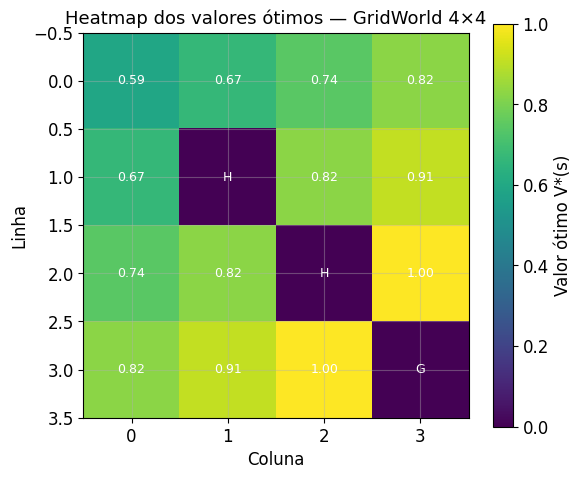

Comparação Policy Iteration vs Value Iteration:
  Policy Iteration: 3 iterações externas
  Value Iteration:  7 sweeps
  Políticas idênticas: True


In [12]:
V_grade = vi_valores.reshape(env.rows, env.cols)

plt.figure(figsize=(6, 5))
im = plt.imshow(V_grade, cmap='viridis')
plt.colorbar(im, label='Valor ótimo V*(s)')
for r in range(env.rows):
    for c in range(env.cols):
        s = env.para_estado(r, c)
        if s == env.estado_meta: rotulo = 'G'
        elif s in env.buracos: rotulo = 'H'
        else: rotulo = f'{V_grade[r, c]:.2f}'
        plt.text(c, r, rotulo, ha='center', va='center', color='white', fontsize=9)
plt.title('Heatmap dos valores ótimos — GridWorld 4×4')
plt.xlabel('Coluna')
plt.ylabel('Linha')
plt.tight_layout()
plt.show()

print("Comparação Policy Iteration vs Value Iteration:")
print(f"  Policy Iteration: {pi_iters} iterações externas")
print(f"  Value Iteration:  {vi_sweeps} sweeps")
print(f"  Políticas idênticas: {np.array_equal(pi_gulosa, vi_gulosa)}")

### Equivalência entre Policy Iteration e Value Iteration

`Políticas idênticas: True` confirma que ambos os algoritmos convergem para a **mesma política ótima**, apesar de percorrerem caminhos diferentes.

- **Policy Iteration** alternou avaliação completa e melhoria em 3 ciclos. Cada avaliação exigiu dezenas de sweeps internos (69 + 208 + 7 ≈ 284 sweeps totais), mas a política estabilizou rapidamente porque o GridWorld é simples.
- **Value Iteration** convergiu em 7 sweeps totais — mais eficiente em número de operações, mas sem separar claramente as duas etapas.

**Comparação justa:** para avaliar o custo real dos dois métodos, conta-se o número total de avaliações de Bellman. Policy Iteration realizou ~284 sweeps internos distribuídos em 3 iterações; Value Iteration realizou 7 sweeps diretamente. Em problemas pequenos, a diferença é negligenciável. Em ambientes maiores, Value Iteration frequentemente é mais econômico porque não precisa avaliar completamente cada política intermediária antes de melhorá-la.

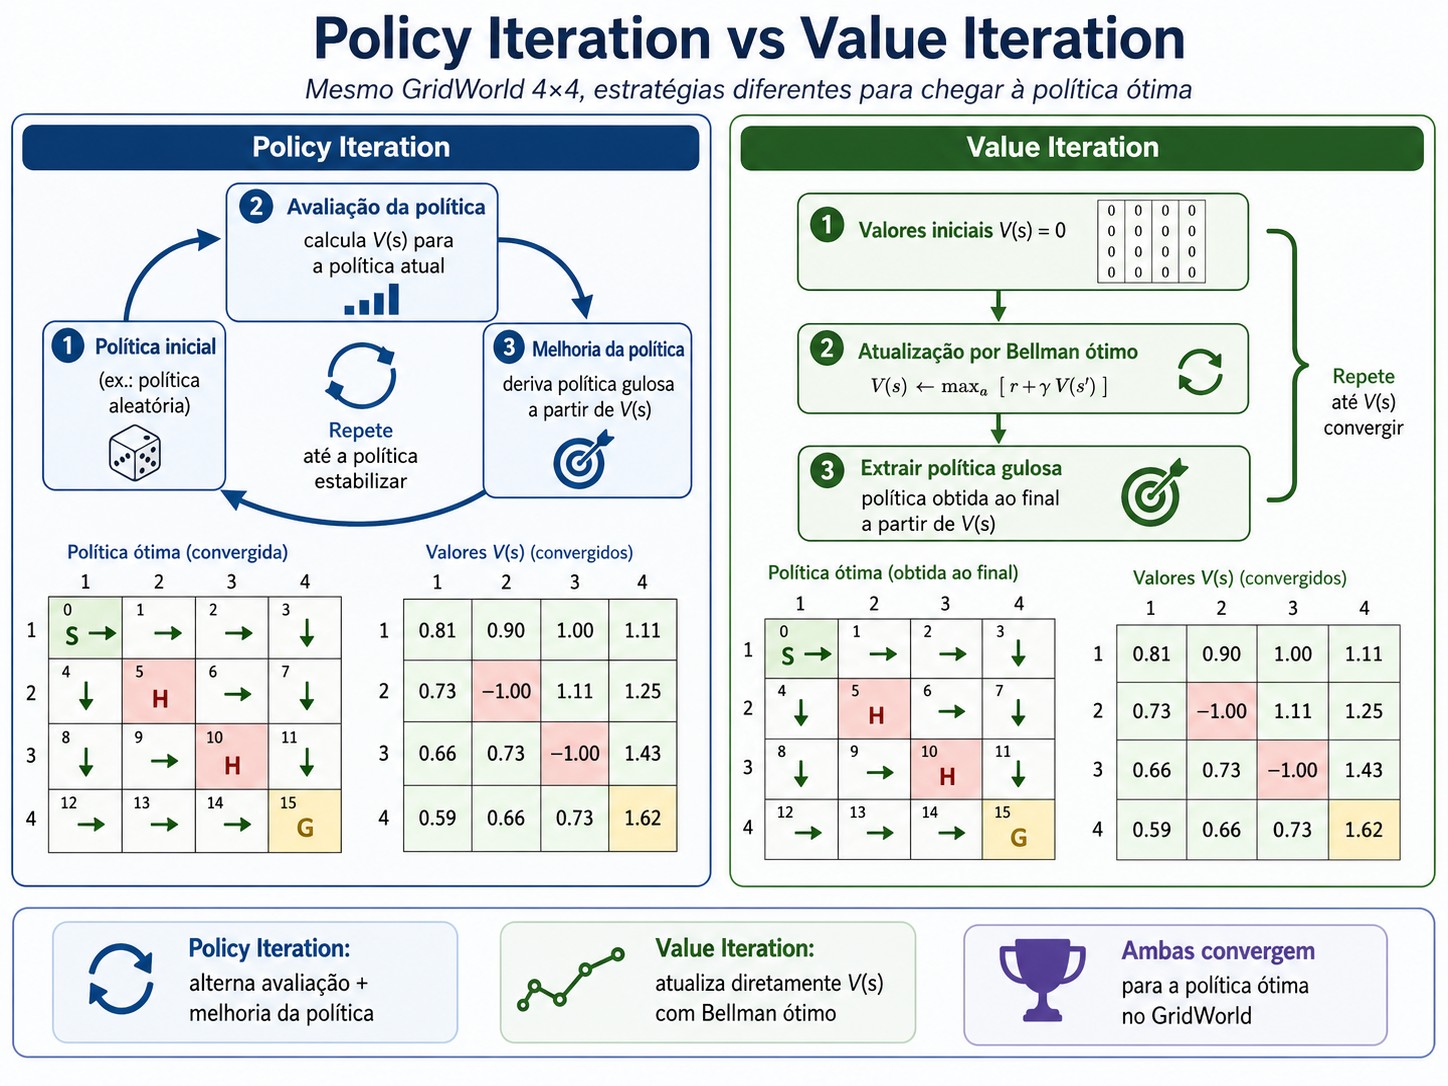

## Bloco 4 — Interpretação pedagógica

O heatmap revela como o valor se propaga a partir do objetivo:

- **Estados próximos ao objetivo** têm valor alto — a recompensa positiva está a poucos passos.
- **Estados vizinhos de buracos** têm valor reduzido — o risco de penalidade está presente mesmo que o objetivo também esteja próximo.
- **Estados distantes ou bloqueados** têm valor baixo — o caminho até o objetivo é longo e sujeito a penalidades acumuladas.

A política ótima não é uma sequência memorizada de movimentos. Ela emerge diretamente da estrutura de valores: em cada estado, o agente simplesmente escolhe a ação que leva ao estado de maior valor.

## Autoavaliação

<details>
<summary>Pergunta 1: Por que a Equação de Bellman permite calcular V(s) de forma recursiva?</summary>

**Resposta:** Porque ela decompõe o valor de um estado em dois termos: a recompensa imediata (que é local e conhecida) mais o valor descontado do próximo estado. Isso cria uma relação entre V(s) e V(s'), permitindo resolver o sistema de equações iterativamente — cada varredura propaga informação dos estados terminais para os estados anteriores.

**Por quê:** Se os valores de estados futuros não estivessem embutidos na fórmula, não haveria como calcular V(s) sem enumerar todos os episódios possíveis.

</details>

<details>
<summary>Pergunta 2: Em que situação a Programação Dinâmica não pode ser aplicada diretamente?</summary>

**Resposta:** Quando o modelo do ambiente não está disponível — ou seja, quando não conhecemos as probabilidades de transição P(s'|s,a) e as recompensas R(s,a). Também quando o espaço de estados é muito grande ou contínuo, tornando inviável percorrer todos os estados em cada varredura.

**Por quê:** A DP exige acesso completo ao modelo para calcular a expectativa sobre todas as transições possíveis. Sem isso, é necessário aprender por interação (Monte Carlo, TD — próximo notebook).

</details>

<details>
<summary>Pergunta 3: Qual é a diferença fundamental entre Policy Iteration e Value Iteration?</summary>

**Resposta:** Na Policy Iteration, a avaliação de política é executada até convergência completa antes de cada melhoria — isso pode exigir muitas varreduras por iteração. Na Value Iteration, cada varredura já incorpora a optimalidade via `max`, sem separar as duas etapas. O resultado final (valores e política ótimos) é idêntico, mas o caminho é estruturalmente diferente.

**Por quê:** Value Iteration converge mais rapidamente em muitos problemas práticos porque não gasta tempo avaliando completamente políticas intermediárias — mas Policy Iteration facilita a compreensão da separação entre avaliação e melhoria.

</details>

## Mapeamento para o Desafio Final

| Competência | Quando usar no Desafio Final |
|---|---|
| Implementar Policy Iteration e Value Iteration | Etapas em que o modelo do ambiente está disponível (ex.: simulação com transições definidas) |
| Explicar a Equação de Bellman recursivamente | Qualquer etapa em que seja necessário justificar por que o agente atribui valor a estados |
| Calcular V*(s) por sweeps iterativos | Verificação de sanidade: o valor convergiu? A política melhorou entre iterações? |
| Identificar quando a DP não se aplica | Contexto para apresentar Monte Carlo e TD — ambientes sem modelo explícito |

**Regra prática:** se o Desafio Final usa um ambiente com modelo totalmente conhecido (transições determinísticas, espaço discreto pequeno), a DP é a solução mais eficiente. Para qualquer outro caso, avance para os métodos *model-free* dos próximos notebooks.

## Bloco 5 — Limites e transição

A Programação Dinâmica calcula valores exatos com garantia de convergência, mas exige duas condições raramente disponíveis em problemas reais:

1. **O modelo completo do ambiente deve estar disponível** — transições, recompensas e estados terminais.
2. **O espaço de estados deve ser pequeno e discreto** — em problemas reais, esse espaço pode ter milhões de estados ou ser contínuo.

Quando o modelo não está disponível, o agente precisa aprender a partir de interações diretas com o ambiente — estimando valores por experiência. Esse é o tema do próximo notebook, que introduz Monte Carlo e TD(0) como métodos *model-free*.

## Principais aprendizados

1. **V(s) e Q(s,a)** quantificam a qualidade de estados e ações sob uma política; a política ótima emerge dessas estimativas.
2. **A Equação de Bellman** conecta recursivamente o valor presente ao retorno futuro — a base de todos os algoritmos desta aula.
3. **Policy Evaluation** calcula V(s) exato para uma política fixa por varreduras iterativas até convergência (δ < θ).
4. **Policy Iteration** alterna avaliação e melhoria com garantia de convergir para a política ótima (Teorema de Melhoria de Política).
5. **Value Iteration** produz a mesma política ótima, mais eficientemente, incorporando optimalidade diretamente em cada varredura — ao custo de menos separação pedagógica entre avaliar e melhorar.

## Glossário — termos introduzidos neste notebook

| Termo (EN) | Tradução (PT) | Descrição |
|---|---|---|
| dynamic programming | programação dinâmica | Calcula valores exatos usando o modelo completo do ambiente (transições e recompensas). |
| policy evaluation | avaliação de política | Processo iterativo que calcula V(s) para uma política fixa até convergência. |
| policy improvement | melhoria de política | Deriva a política gulosa a partir de V(s) para obter uma política melhor. |
| policy iteration | iteração de política | Alterna avaliação e melhoria até a política estabilizar. |
| value iteration | iteração de valor | Incorpora optimalidade diretamente na atualização de V(s) usando max sobre as ações. |

> Glossário completo do curso: [docs/glossario.md](../../docs/glossario.md)

## Leituras e referências

- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2ª ed.). MIT Press. Caps. 3 e 4. Disponível em: http://incompleteideas.net/book/the-book-2nd.html. Acesso em: abril 2026.
- Bellman, R. (1957). *Dynamic Programming*. Princeton University Press.
- Puterman, M. L. (1994). *Markov Decision Processes: Discrete Stochastic Dynamic Programming*. Wiley.